In [ ]:
import pandas as pd
import numpy as np
import pyemu
import yaml
import math
import os
from scipy.special import exp1
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [ ]:
# set up path
target_dir = r"\Python\Personal\proj6\codes\runs\sandbox"
rel_t_d = os.path.relpath(target_dir, os.getcwd()) 
os.chdir(rel_t_d)

In [ ]:
##########################
### pit-centric domain ###
##########################

# number of wells
n_wells = 2

# number of individuals in the population in the decision variable space
num_reals = 150

# bounds of coordinate system
x_min, x_max = -50, 50
y_min, y_max = -50, 50

# wells cannot be within this many units of the center
no_go_radius = 10.0

# range of pumping rates [m3/day]
q_min, q_max = 6.5, 65

# aquifer properties
T_val = 100.0 # [m2/day]
S_val = 0.001 # [-]
t_eval_val = 365.0 # [day]

######################
### parameter list ###
######################

# build parameter data frame
par_names = []
for i in range(1, n_wells + 1):
    par_names.extend([f"well_{i}_x", f"well_{i}_y", f"well_{i}_q"])

if "xc" not in par_names:
    par_names.append("xc")

#######################
### initialize pest ###
#######################

# initialize an empty PEST control file (v2)
pst = pyemu.pst_utils.generic_pst(par_names=par_names)
pdf = pst.parameter_data

###########################
### populate pest files ###
###########################

# randomize compliance point y-position
Yc = np.random.choice([y_min, y_max])

# configure well position metadata
well_pars = [p for p in par_names if "well" in p]
pdf.loc[well_pars, ["partrans", "parchglim", "pargp"]] = ["none", "factor", "well_pos"]
pdf.loc[well_pars, ["parlbnd", "parubnd"]] = [x_min, x_max]

# configure pumping rate metadata
well_q_pars = [p for p in par_names if "_q" in p]
pdf.loc[well_q_pars, ["partrans", "parchglim", "pargp"]] = ["none", "factor", "pumping_rate"]
pdf.loc[well_q_pars, "parlbnd"] = q_min
pdf.loc[well_q_pars, "parubnd"] = q_max

# configure compliance point metadata
pdf.loc["xc", ["partrans", "parchglim", "pargp"]] = ["none", "factor", "compliance"]
pdf.loc["xc", ["parlbnd", "parubnd"]] = [x_min, x_max]

###################
### random draw ###
###################

# initialize within constraints
valid_data = []
while len(valid_data) < num_reals:
    # generate random values for all parameters at once
    row = np.random.uniform(0, 1, len(par_names)) # start with 0-1 scale
    
    # scale each parameter to its specific bounds
    scaled_row = []
    for p_name, val in zip(par_names, row):
        lb = pdf.loc[p_name, "parlbnd"]
        ub = pdf.loc[p_name, "parubnd"]
        scaled_row.append(lb + val * (ub - lb))
    
    scaled_row = np.array(scaled_row)
    
    # no-go zone check
    # the first 2*n_wells are X and Y
    # skip Q for the distance check
    well_coords = []
    for i in range(1, n_wells + 1):
        well_coords.append([scaled_row[par_names.index(f"well_{i}_x")], 
                            scaled_row[par_names.index(f"well_{i}_y")]])
    
    distances = np.linalg.norm(well_coords, axis=1)
    if np.all(distances > no_go_radius):
        valid_data.append(scaled_row)

pop = pyemu.ParameterEnsemble(pst=pst, df=pd.DataFrame(valid_data, columns=par_names))

# generate random ensemble for PESTPP-MOU
np.random.seed(np.random.randint(1, 100000))
pop = pyemu.ParameterEnsemble(pst=pst, df=pd.DataFrame(valid_data, columns=par_names))

# select a random realization from the initial population by picking one index name at random from the ensemble
yc = np.random.choice([y_min, y_max])
selected_real = np.random.choice(pop.index)
pst.parameter_data.loc[par_names, "parval1"] = pop.loc[selected_real, par_names].values

#################################
### centre of mass of pumping ###
#################################

# pumping-rate-weighted average of well positions
total_q = sum(pst.parameter_data.loc[f"well_{i}_q", "parval1"] for i in range(1, n_wells + 1))
com_x = sum(pst.parameter_data.loc[f"well_{i}_x", "parval1"] * 
            pst.parameter_data.loc[f"well_{i}_q", "parval1"] for i in range(1, n_wells + 1)) / total_q
com_y = sum(pst.parameter_data.loc[f"well_{i}_y", "parval1"] * 
            pst.parameter_data.loc[f"well_{i}_q", "parval1"] for i in range(1, n_wells + 1)) / total_q

# radial distance from CoM to compliance point and pit (targets)
xc_val = pst.parameter_data.loc["xc", "parval1"]
dist_com_to_compliance = np.sqrt((com_x - xc_val)**2 + (com_y - yc)**2)
dist_com_to_pit = np.sqrt(com_x**2 + com_y**2)

#########################################
### generate domain configuration yml ###
#########################################

theis_cfg = {
    'T': T_val, 
    'S': S_val, 
    't_eval': t_eval_val,
    'well_at_compliance': {'Q': float(total_q), 'radial_dist': float(dist_com_to_compliance)},
    'well_at_pit': {'Q': float(total_q), 'radial_dist': float(dist_com_to_pit)}
}

with open("config.yml", "w") as f:
    yaml.dump(theis_cfg, f)

# calculate drawdowns using the logic from run_theis_forward_dd.py
def get_s(Q, r):
    u = (r**2 * S_val) / (4.0 * T_val * t_eval_val)
    return (Q / (4.0 * math.pi * T_val)) * exp1(u)

s_compliance = get_s(total_q, dist_com_to_compliance)
s_pit = get_s(total_q, dist_com_to_pit)

###########################
### objective functions ###
###########################

# min xc
new_obs_xc = {"obsnme": "obj_min_xc", "obsval": 0.0, "weight": 1.0, "obgnme": "min_xc_gp"}
for col, val in new_obs_xc.items():
    pst.observation_data.loc["obj_min_xc", col] = val

# min total Q
new_obs_q = {"obsnme": "obj_min_q", "obsval": 0.0, "weight": 0.1, "obgnme": "min_q_gp"}
for col, val in new_obs_q.items():
    pst.observation_data.loc["obj_min_q", col] = val

# max drawdown at compliance point (min negative drawdown)
new_obs_s = {"obsnme": "obj_max_s_compliance", "obsval": 0.0, "weight": 0.1, "obgnme": "max_s_compliance_gp"}
for col, val in new_obs_s.items():
    pst.observation_data.loc["obj_max_s_cp", col] = val

# max drawdown at open pit (min negative drawdown)
new_obs_s = {"obsnme": "obj_max_s_pit", "obsval": 0.0, "weight": 0.1, "obgnme": "max_s_pit_gp"}
for col, val in new_obs_s.items():
    pst.observation_data.loc["obj_max_s_pit", col] = val

########################
### write and record ###
########################

# set control data for PEST control file (v2)
pst.control_data.noptmax = 0

# write PEST control file (v2)
pst_filename = "fwd_model.pst"
pst.write(pst_filename, version = 2)

# record to external file in the current directory
pop.to_csv("pop.csv")

######################
### output summary ###
######################

print(f"Realization: {selected_real}")

# well summary table
well_data = [{
    "Well": f"{i}",
    "X": pst.parameter_data.loc[f"well_{i}_x", "parval1"],
    "Y": pst.parameter_data.loc[f"well_{i}_y", "parval1"],
    "Q (m3/d)": pst.parameter_data.loc[f"well_{i}_q", "parval1"]
} for i in range(1, n_wells + 1)]

# append CoM as a final row
well_data.append({
    "Well": "CoM",
    "X": com_x,
    "Y": com_y,
    "Q (m3/d)": total_q
})

# drawdown summary table
drawdown_data = [
    {"Target": "Compliance Point", "Radius (m)": dist_com_to_compliance, "Drawdown (m)": s_compliance},
    {"Target": "Pit Centre", "Radius (m)": dist_com_to_pit, "Drawdown (m)": s_pit}
]

# display well table
display(pd.DataFrame(well_data).style.format({
    "X": "{:.2f}", 
    "Y": "{:.2f}", 
    "Q (m3/d)": "{:.2f}"
}).hide(axis='index'))

# display drawdown table
display(pd.DataFrame(drawdown_data).style.format({
    "Radius (m)": "{:.2f}", 
    "Drawdown (m)": "{:.2f}"
}).hide(axis='index'))

In [ ]:
##############
### set up ###
##############

fig = go.Figure()

# access the underlying dataframe using the internal _df attribute
df = pop._df

######################################
### two well example visualization ###
######################################

# domain
fig.add_shape(type="rect", x0=x_min, y0=y_min, x1=x_max, y1=y_max, line=dict(color="black"), opacity=0.1)

# no-go area
fig.add_shape(type="circle", x0=-no_go_radius, y0=-no_go_radius, x1=no_go_radius, y1=no_go_radius, line=dict(color="black", dash="dash"))

# targets with drawdown labels
fig.add_trace(go.Scatter(x=[0], y=[0], mode='markers+text', text=[f"Open Pit<br>s: {s_pit:.2f}m"],
                         marker=dict(color='black', size=10, symbol='hexagon'), name="Open Pit", textposition="top center"))

fig.add_trace(go.Scatter(x=[xc_val], y=[yc], mode='markers+text', text=[f"Compliance Point<br>s: {s_compliance:.2f}m"],
                         marker=dict(color='yellow', size=10, symbol='star', line=dict(width=1, color='black')), 
                         name="Compliance Point", textposition="top center" if yc == y_min else "bottom center"))

# well ensembles
fig.add_trace(go.Scatter(x=df["well_1_x"], y=df["well_1_y"], mode='markers', marker=dict(color='lightskyblue', opacity=0.2), name="Well 1 Ensemble"))
fig.add_trace(go.Scatter(x=df["well_2_x"], y=df["well_2_y"], mode='markers', marker=dict(color='lightcoral', opacity=0.2), name="Well 2 Ensemble"))

# selected wells
fig.add_trace(go.Scatter(x=[pst.parameter_data.loc["well_1_x", "parval1"]], y=[pst.parameter_data.loc["well_1_y", "parval1"]],
                         mode='markers+text', text=["Well 1"], marker=dict(color='dodgerblue', size=10), name="Well 1 Selected", textposition="top center"))
fig.add_trace(go.Scatter(x=[pst.parameter_data.loc["well_2_x", "parval1"]], y=[pst.parameter_data.loc["well_2_y", "parval1"]],
                         mode='markers+text', text=["Well 2"], marker=dict(color='crimson', size=10, symbol='square'), name="Well 2 Selected", textposition="top center"))

# CoM and distance lines
fig.add_trace(go.Scatter(x=[com_x], y=[com_y], mode='markers+text', text=["CoM"], marker=dict(color='black', size=12, symbol='x'), name="Pumping Center of Mass", textposition="top center"))
fig.add_trace(go.Scatter(x=[com_x, xc_val, None, com_x, 0], y=[com_y, yc, None, com_y, 0], 
                         mode='lines', line=dict(color='grey', width=1, dash='dot'), showlegend=False))

fig.update_layout(
    xaxis_title="X Coordinate", 
    yaxis_title="Y Coordinate", 
    template="plotly_white", 
    width=700, 
    height=700,
    title=(f"Theis Analysis: Realization {selected_real}<br>"
           f"<sup>Aquifer Parameters: T={T_val} m²/d, S={S_val}</sup>")
)

fig.show()

In [ ]:
#############################################
# drawdown vs time plot at compliance point #
#############################################

# time steps for drawdown evaluation
t_series = np.arange(5, t_eval_val + 5, 5)

# coordinates for wells and compliance point
# wells
w1_coords = (pst.parameter_data.loc["well_1_x", "parval1"], pst.parameter_data.loc["well_1_y", "parval1"])
w2_coords = (pst.parameter_data.loc["well_2_x", "parval1"], pst.parameter_data.loc["well_2_y", "parval1"])
# compliance point
cp_coords = (xc_val, yc) 

# calculae radial distances to compliance point
def dist(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

r1_cp = dist(w1_coords, cp_coords)
r2_cp = dist(w2_coords, cp_coords)
r_com_cp = dist((com_x, com_y), cp_coords)

# calculate trace drawdowns at compliance point using Theis solution
def theis_s(Q, r, t):
    u = (r**2 * S_val) / (4.0 * T_val * t)
    return (Q / (4.0 * math.pi * T_val)) * exp1(u)

s1_cp = theis_s(pst.parameter_data.loc["well_1_q", "parval1"], r1_cp, t_series)
s2_cp = theis_s(pst.parameter_data.loc["well_2_q", "parval1"], r2_cp, t_series)
s_total_cp = s1_cp + s2_cp
s_com_cp = theis_s(total_q, r_com_cp, t_series)

# plot
plt.figure(figsize=(10, 5))
plt.plot(t_series, s1_cp, label='Well 1', linestyle='-')
plt.plot(t_series, s2_cp, label='Well 2', linestyle='-')
plt.plot(t_series, s_total_cp, label='Superposition', color='black', lw=2)
plt.plot(t_series, s_com_cp, label='Centre of Mass', color='red', linestyle='--')

plt.title(f'Drawdown vs Time at Compliance Point')
plt.xlabel('Time (days)')
plt.ylabel('Drawdown (m)')
plt.ylim(0, max(s_total_cp)*1.1)
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.show()


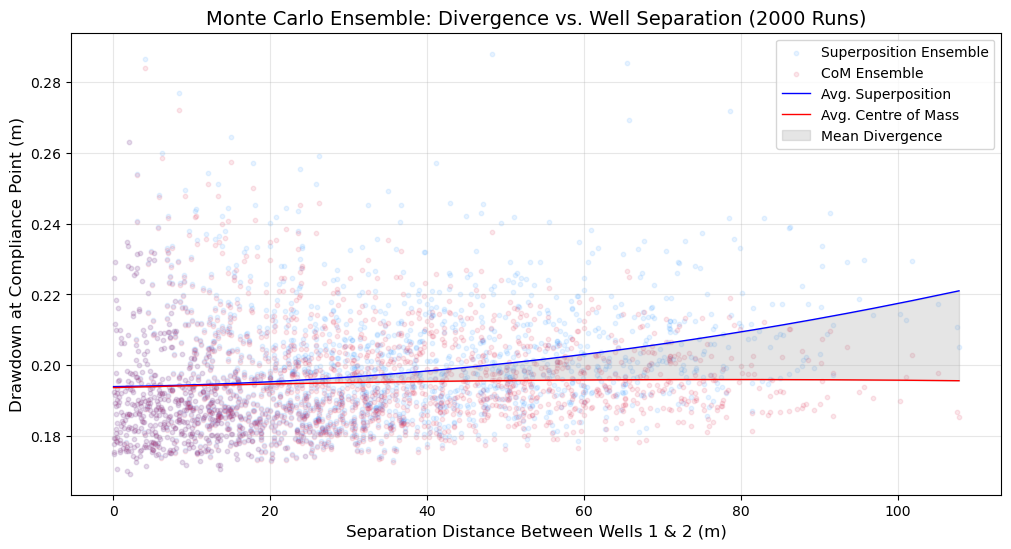

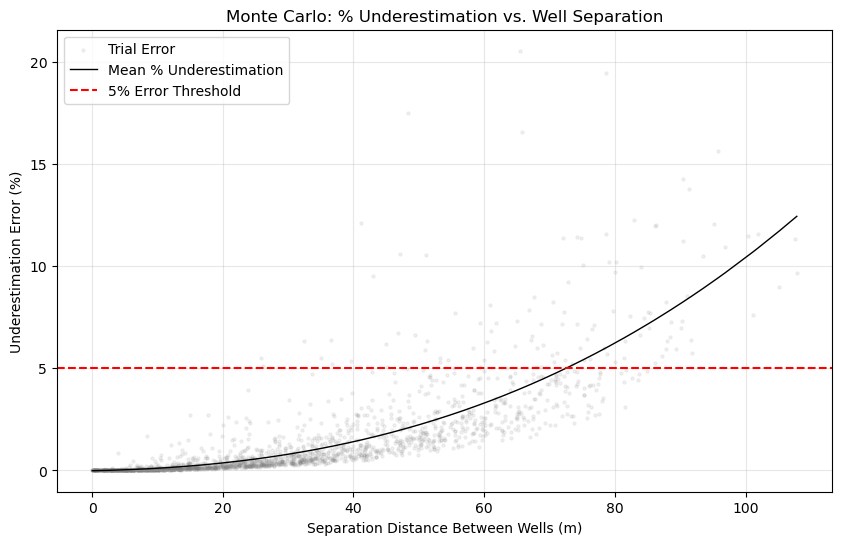

In [ ]:
### distance is squared (r**2) inside the Theis function
### therefore the drawdown doesn't decrease linearly
### thus the average of two drawdowns is never the same as the drawdown at the average distance

########################################################
### monte carlo proof - drawdown at compliance point ### 
########################################################

# monte carlo parameters
num_trials = 2000
T, S, t = T_val, S_val, t_eval_val
q1 = pst.parameter_data.loc["well_1_q", "parval1"]
q2 = pst.parameter_data.loc["well_2_q", "parval1"]
q_total = q1 + q2

# initialize dict for results
results = []

def get_valid_well():
    """Generates a well position that honors the no go radius from the pit centre"""
    while True:
        x = np.random.uniform(x_min, x_max)
        y = np.random.uniform(y_min, y_max)
        if math.sqrt(x**2 + y**2) >= no_go_radius:
            return np.array([x, y])

# run monte carlo trials
for _ in range(num_trials):
    # place two valid wells
    w1 = get_valid_well()
    w2 = get_valid_well()

    # calculate radial distances to compliance point
    r1 = np.linalg.norm(w1 - cp_coords)
    r2 = np.linalg.norm(w2 - cp_coords)
    
    # calculate drawdown assuming superposition
    u1 = (r1**2 * S) / (4.0 * T * t)
    u2 = (r2**2 * S) / (4.0 * T * t)
    s_true = (q1/(4*np.pi*T))*exp1(u1) + (q2/(4*np.pi*T))*exp1(u2)
    
    # calculate drawdown assuming CoM approximation
    r_com = (r1*q1 + r2*q2) / q_total # r_com = weighted average distance
    u_com = (r_com**2 * S) / (4.0 * T * t)
    s_com = (q_total/(4*np.pi*T))*exp1(u_com)
    
    # store the separation distance and the resulting error
    separation = abs(r1 - r2)
    error = s_true - s_com
    results.append([separation, s_true, s_com, error])

# convert to numpy array for easy indexing
res = np.array(results)
sep_dist = res[:, 0]
true_s = res[:, 1]
com_s = res[:, 2]

# plot
plt.figure(figsize=(12, 6))
plt.scatter(sep_dist, true_s, color='dodgerblue', alpha=0.1, s=10, label='Superposition Ensemble')
plt.scatter(sep_dist, com_s, color='crimson', alpha=0.1, s=10, label='CoM Ensemble')

# polyfit shows the mean behavior of the ensembles
z_true = np.polyfit(sep_dist, true_s, 2)
p_true = np.poly1d(z_true)
z_com = np.polyfit(sep_dist, com_s, 2)
p_com = np.poly1d(z_com)

sorted_sep = np.sort(sep_dist)
plt.plot(sorted_sep, p_true(sorted_sep), 'b-', lw=1, label='Avg. Superposition')
plt.plot(sorted_sep, p_com(sorted_sep), 'r-', lw=1, label='Avg. Centre of Mass')

# format
plt.fill_between(sorted_sep, p_true(sorted_sep), p_com(sorted_sep), color='grey', alpha=0.2, label='Mean Divergence')
plt.title(f'Monte Carlo Ensemble: Divergence vs. Well Separation ({num_trials} Runs)', fontsize=14)
plt.xlabel('Separation Distance Between Wells 1 & 2 (m)', fontsize=12)
plt.ylabel('Drawdown at Compliance Point (m)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

######################################
### monte carlo proof - % at error ### 
######################################

# 1. calculate % error for each trial in ensemble
p_errors = (true_s - com_s) / true_s * 100

# plot
plt.figure(figsize=(10, 6))
plt.scatter(sep_dist, p_errors, color='grey', alpha=0.1, s=5, label='Trial Error')

# polyfit shows the mean behavior of the ensembles
idx = np.argsort(sep_dist)
z = np.polyfit(sep_dist, p_errors, 3)
p_trend = np.poly1d(z)
plt.plot(sep_dist[idx], p_trend(sep_dist[idx]), 'k-', lw=1, label='Mean % Underestimation')

# annotate
plt.axhline(5, color='red', linestyle='--', label='5% Error Threshold') # define threshold for "safe zone"
plt.title('Monte Carlo: % Underestimation vs. Well Separation')
plt.xlabel('Separation Distance Between Wells (m)')
plt.ylabel('Underestimation Error (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### below in progress

In [259]:
from SALib.sample import saltelli
from SALib.analyze import sobol
import numpy as np

# 1. Define the Problem
# We vary T, S, Well Count (n), and coordinates for up to 5 wells
problem = {
    'num_vars': 13, # T, S, n, (x1,y1, x2,y2, x3,y3, x4,y4, x5,y5)
    'names': ['T', 'S', 'n_wells', 
              'x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4', 'x5', 'y5'],
    'bounds': [
        [50.0, 150.0],      # T
        [0.0001, 0.01],     # S
        [1.5, 5.5],         # n_wells (will be rounded to 2, 3, 4, or 5)
        *([[-50, 50], [-50, 50]] * 5) # x and y bounds for 5 wells
    ]
}

# 2. Generate Samples
# Saltelli generates N * (2D + 2) samples
param_values = saltelli.sample(problem, 1024)

# 3. Evaluation Loop
Y = []
for p in param_values:
    T_i, S_i, n_float = p[0], p[1], p[2]
    n = int(round(n_float))
    
    # Extract coordinates for the active wells
    # coords are in pairs starting from index 3
    active_coords = p[3:3 + (2 * n)].reshape(n, 2)
    
    # Filter by no_go_radius (if invalid, we skip or penalize)
    valid_wells = [w for w in active_coords if np.linalg.norm(w) >= no_go_radius]
    if len(valid_wells) < n:
        # If random draw hits the no-go zone, we can treat it as a 'dead' well
        # or just use what's left. For Sobol, consistency is key.
        n = len(valid_wells)
    
    if n < 1: 
        Y.append(0)
        continue

    # Calculate Drawdowns at CP
    q_each = 70.0 / n # Keep total Q constant to isolate spatial/n effect
    
    # Superposition (Truth)
    s_true = sum(theis_s(q_each, np.linalg.norm(w - cp), t_eval_val, T_i, S_i) 
                 for w in valid_wells)
    
    # CoM (Approx)
    com_pos = np.mean(valid_wells, axis=0)
    r_com = np.linalg.norm(com_pos - cp)
    s_com = theis_s(70.0, r_com, t_eval_val, T_i, S_i)
    
    # Output: % Error
    error = (s_true - s_com) / s_true * 100 if s_true > 0 else 0
    Y.append(error)

# 4. Analyze
Si = sobol.analyze(problem, np.array(Y))


ModuleNotFoundError: No module named 'SALib'